### **What is transfer learning?**


Transfer learning allows us to take the patterns (also called weights) another model has learned from another problem and use them for our own problem.

For example, we can take the patterns a computer vision model has learned from datasets such as ImageNet (millions of images of different objects) and use them to power our FoodVision Mini model.

Or we could take the patterns from a language model (a model that's been through large amounts of text to learn a representation of language) and use them as the basis of a model to classify different text samples.

The premise remains: find a well-performing existing model and apply it to your own problem.

### **Where to find pre trained models?**

1.Pytorch domain libraries

2.Hugging face hub

3.timm

4.Paperswithcode

## 0.Getting setup

In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
import os 
import zipfile
from pathlib import Path
import requests

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it... 
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)
    
    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...") 
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

data\pizza_steak_sushi directory exists.


In [4]:
train_dir = image_path/"train"
test_dir = image_path/"test"



### 2. Create dataset and dataloaders

When using a pretrained model, it's important that your custom data going into the model is prepared in the same way as the original training data that went into the model.

In [5]:
from torchvision import transforms
from torch import nn
manual_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])


In [6]:
import data_setup

train_dataloader,test_dataloader,class_names,class_dict = data_setup.create_dataloaders(
train_dir = train_dir,test_dir = test_dir , 
train_transform = manual_transform,test_transform = manual_transform,batch_size = 32 
)

#When using transforms.Normalise() it is neccessary to use it in both train and test dataloaders

In [7]:
## Getting a pre trained model

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT #DEFAULT = best available weights from pretraining on ImageNet
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

now To access the transforms associated with out weights , we can use `transforms()` method


In [8]:
#Get the transforms used to create our pretrained weights
auto_transform = weights.transforms()
auto_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

Notice how auto_transforms is very similar to manual_transforms, the only difference is that auto_transforms came with the model architecture we chose, where as we had to create manual_transforms by hand.

The benefit of automatically creating a transform through `weights.transforms()` is that you ensure you're using the same data transformation as the pretrained model used when it was trained.

However, the tradeoff of using automatically created transforms is a lack of customization.

We can use `auto_transforms` to create DataLoaders with `create_dataloaders()` just as before.

In [9]:
train_dataloader,test_dataloader,class_names,class_dict

(<torch.utils.data.dataloader.DataLoader at 0x1301d27b4c0>,
 ['pizza', 'steak', 'sushi'],
 {'pizza': 0, 'steak': 1, 'sushi': 2})

### 3.0 Getting a pre trained model

Alright, here comes the fun part!

Over the past few notebooks we've been building PyTorch neural networks from scratch.

And while that's a good skill to have, our models haven't been performing as well as we'd like.

That's where **transfer learning** comes in.

The whole idea of transfer learning is to **take an already well-performing model on a problem-space similar** to yours and then customise it to your use case.

| Architecture backbone | Code |
| :--- | :--- |
| [ResNet](#)'s | `torchvision.models.resnet18()`, `torchvision.models.resnet50()` ... |
| [VGG](#) (similar to what we used for TinyVGG) | `torchvision.models.vgg16()` |
| [EfficientNet](#)'s | `torchvision.models.efficientnet_b0()`, `torchvision.models.efficientnet_b1()` ... |
| [VisionTransformer](#) (ViT's) | `torchvision.models.vit_b_16()`, `torchvision.models.vit_b_32()` ... |
| [ConvNeXt](#) | `torchvision.models.convnext_tiny()`, `torchvision.models.convnext_small()` ... |
| More available in `torchvision.models` | `torchvision.models...` |

### 3.1 Which pre trained model should you use?

It depends on your problem/the device you're working with.

Generally, the higher number in the model name (e.g. efficientnet_b0() -> efficientnet_b1() -> efficientnet_b7()) means better performance but a larger model.

You might think better performance is always better, right?

That's true but some better performing models are too big for some devices.

For example, say you'd like to run your model on a mobile-device, you'll have to take into account the limited compute resources on the device, thus you'd be looking for a smaller model.

But if you've got unlimited compute power, as The Bitter Lesson states, you'd likely take the biggest, most compute hungry model you can.

**Understanding this performance vs. speed vs. size tradeoff will come with time and practice.**


### 3.2 Setting up a pre trained model

The pretrained model we're going to be using is `torchvision.models.efficientnet_b0()`.

The architecture is from the paper : 

In [10]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

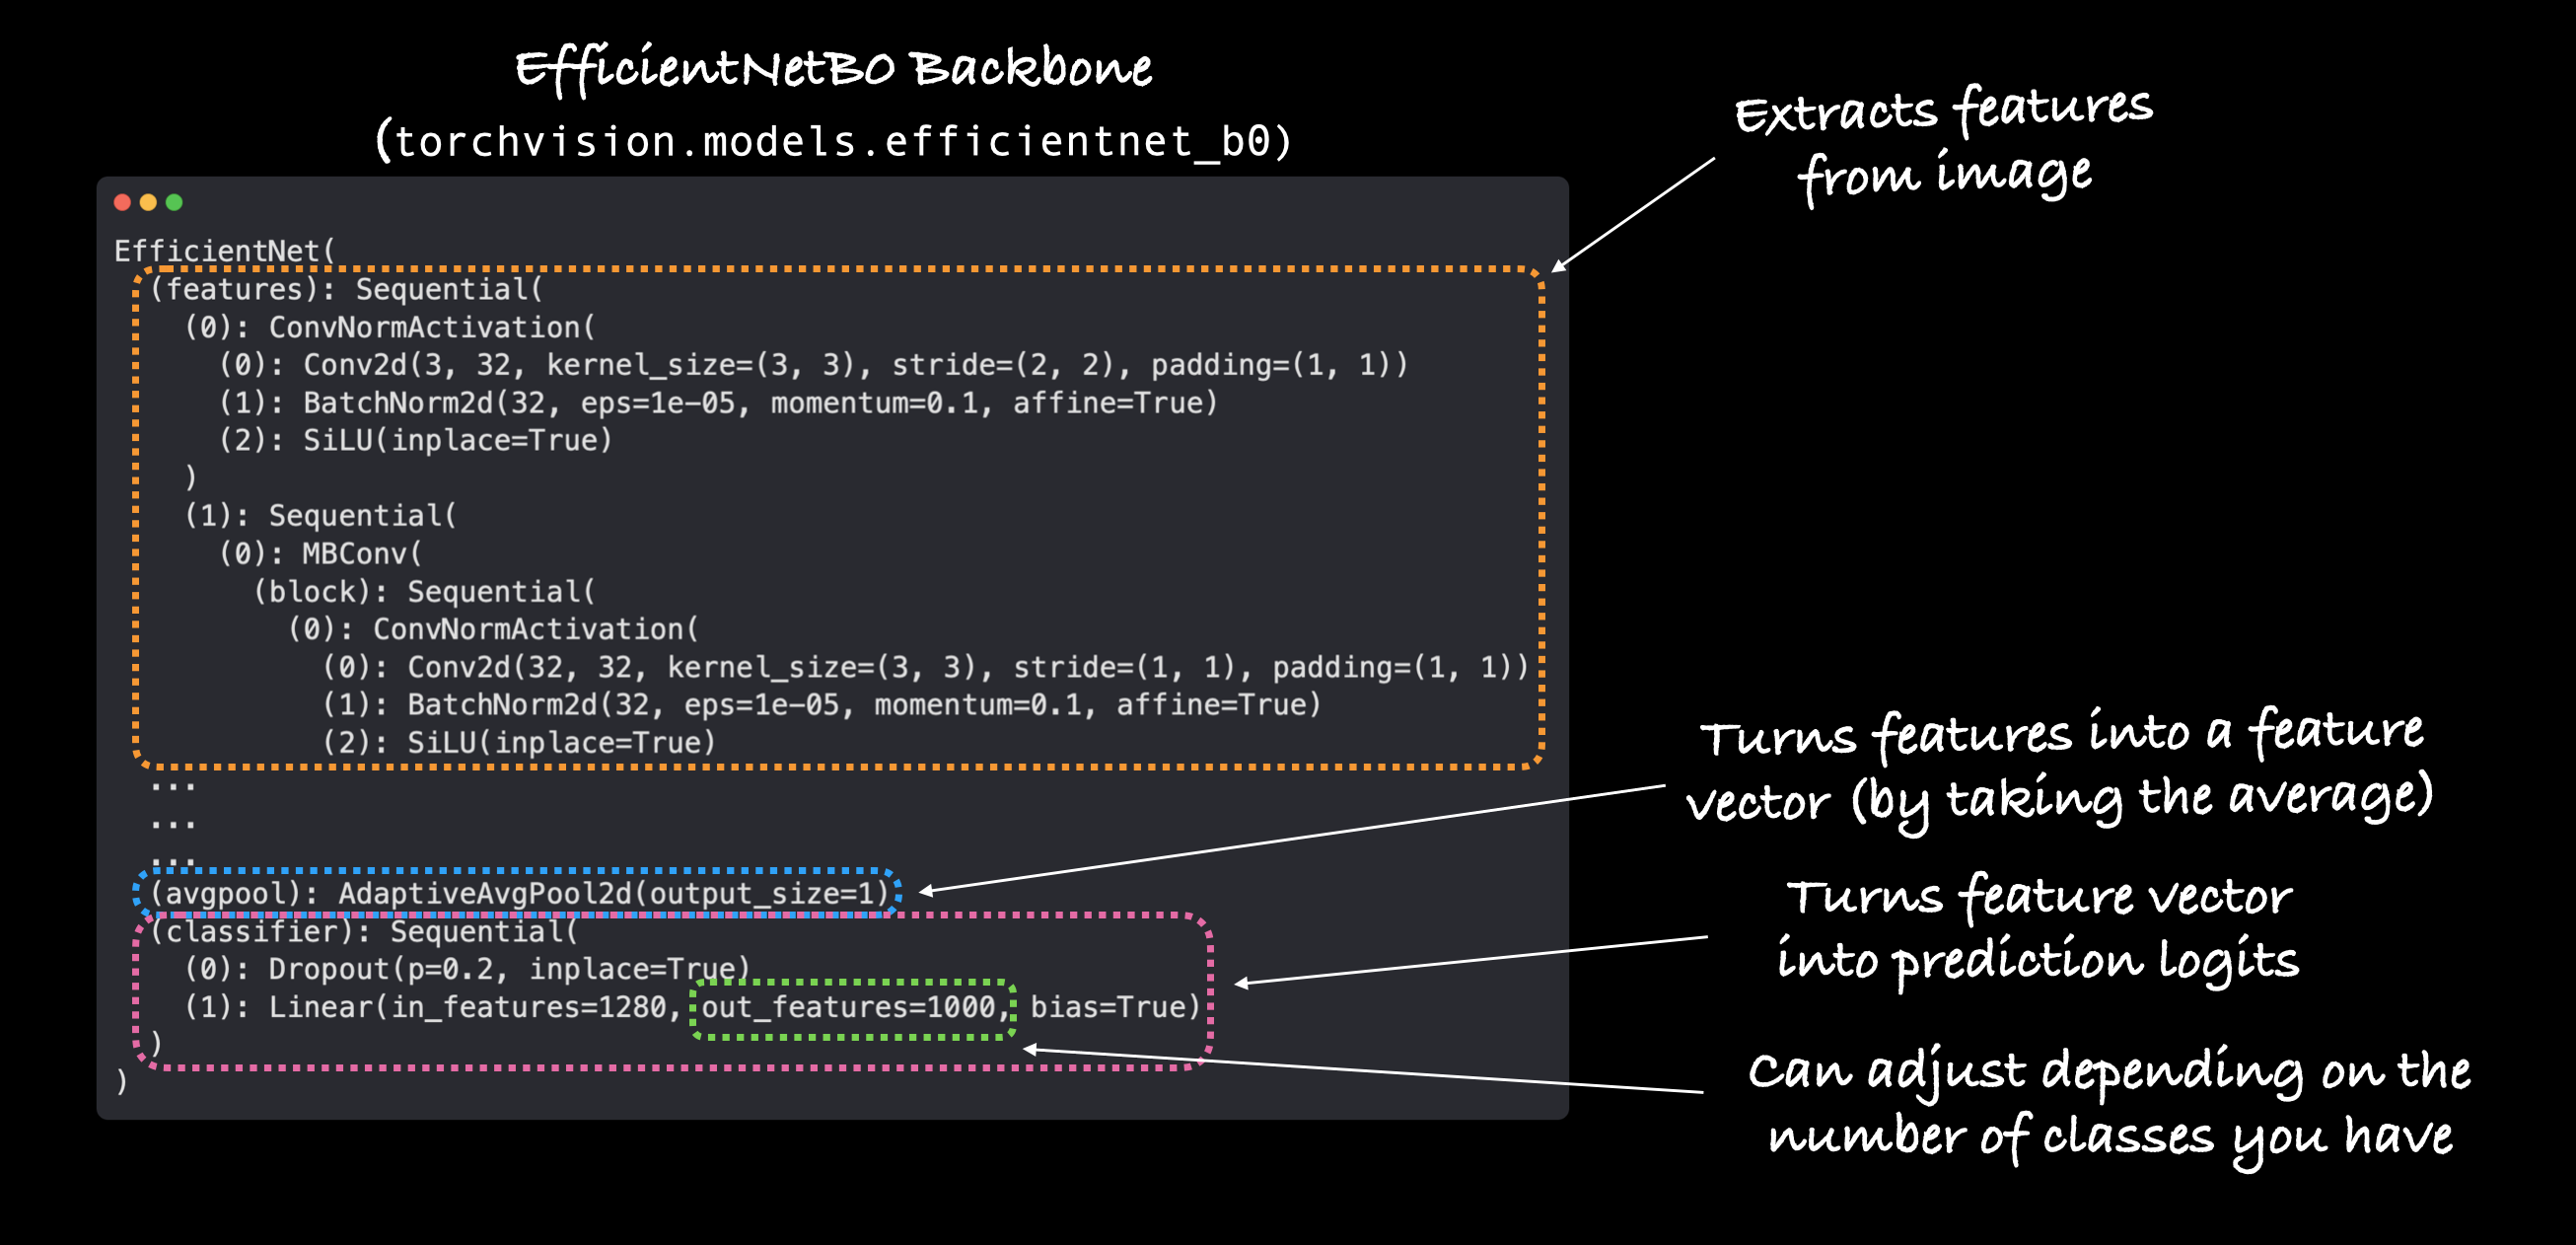

### 3.3 Getting summary of our model with `torchinfo.summary()`

In [11]:
from torchinfo import summary
summary(model = model, input_size = (32,3,244,244),
#col_names = ["input_size"], #uncomment for smaleer output
col_names = ['input_size','output_size','num_params','trainable'],
col_width = 20,
row_settings = ['var_names']

)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [32, 3, 244, 244]    [32, 1000]           --                   True
├─Sequential (features)                                      [32, 3, 244, 244]    [32, 1280, 8, 8]     --                   True
│    └─Conv2dNormActivation (0)                              [32, 3, 244, 244]    [32, 32, 122, 122]   --                   True
│    │    └─Conv2d (0)                                       [32, 3, 244, 244]    [32, 32, 122, 122]   864                  True
│    │    └─BatchNorm2d (1)                                  [32, 32, 122, 122]   [32, 32, 122, 122]   64                   True
│    │    └─SiLU (2)                                         [32, 32, 122, 122]   [32, 32, 122, 122]   --                   --
│    └─Sequential (1)                                        [32, 32, 122, 122]   [32, 16, 122

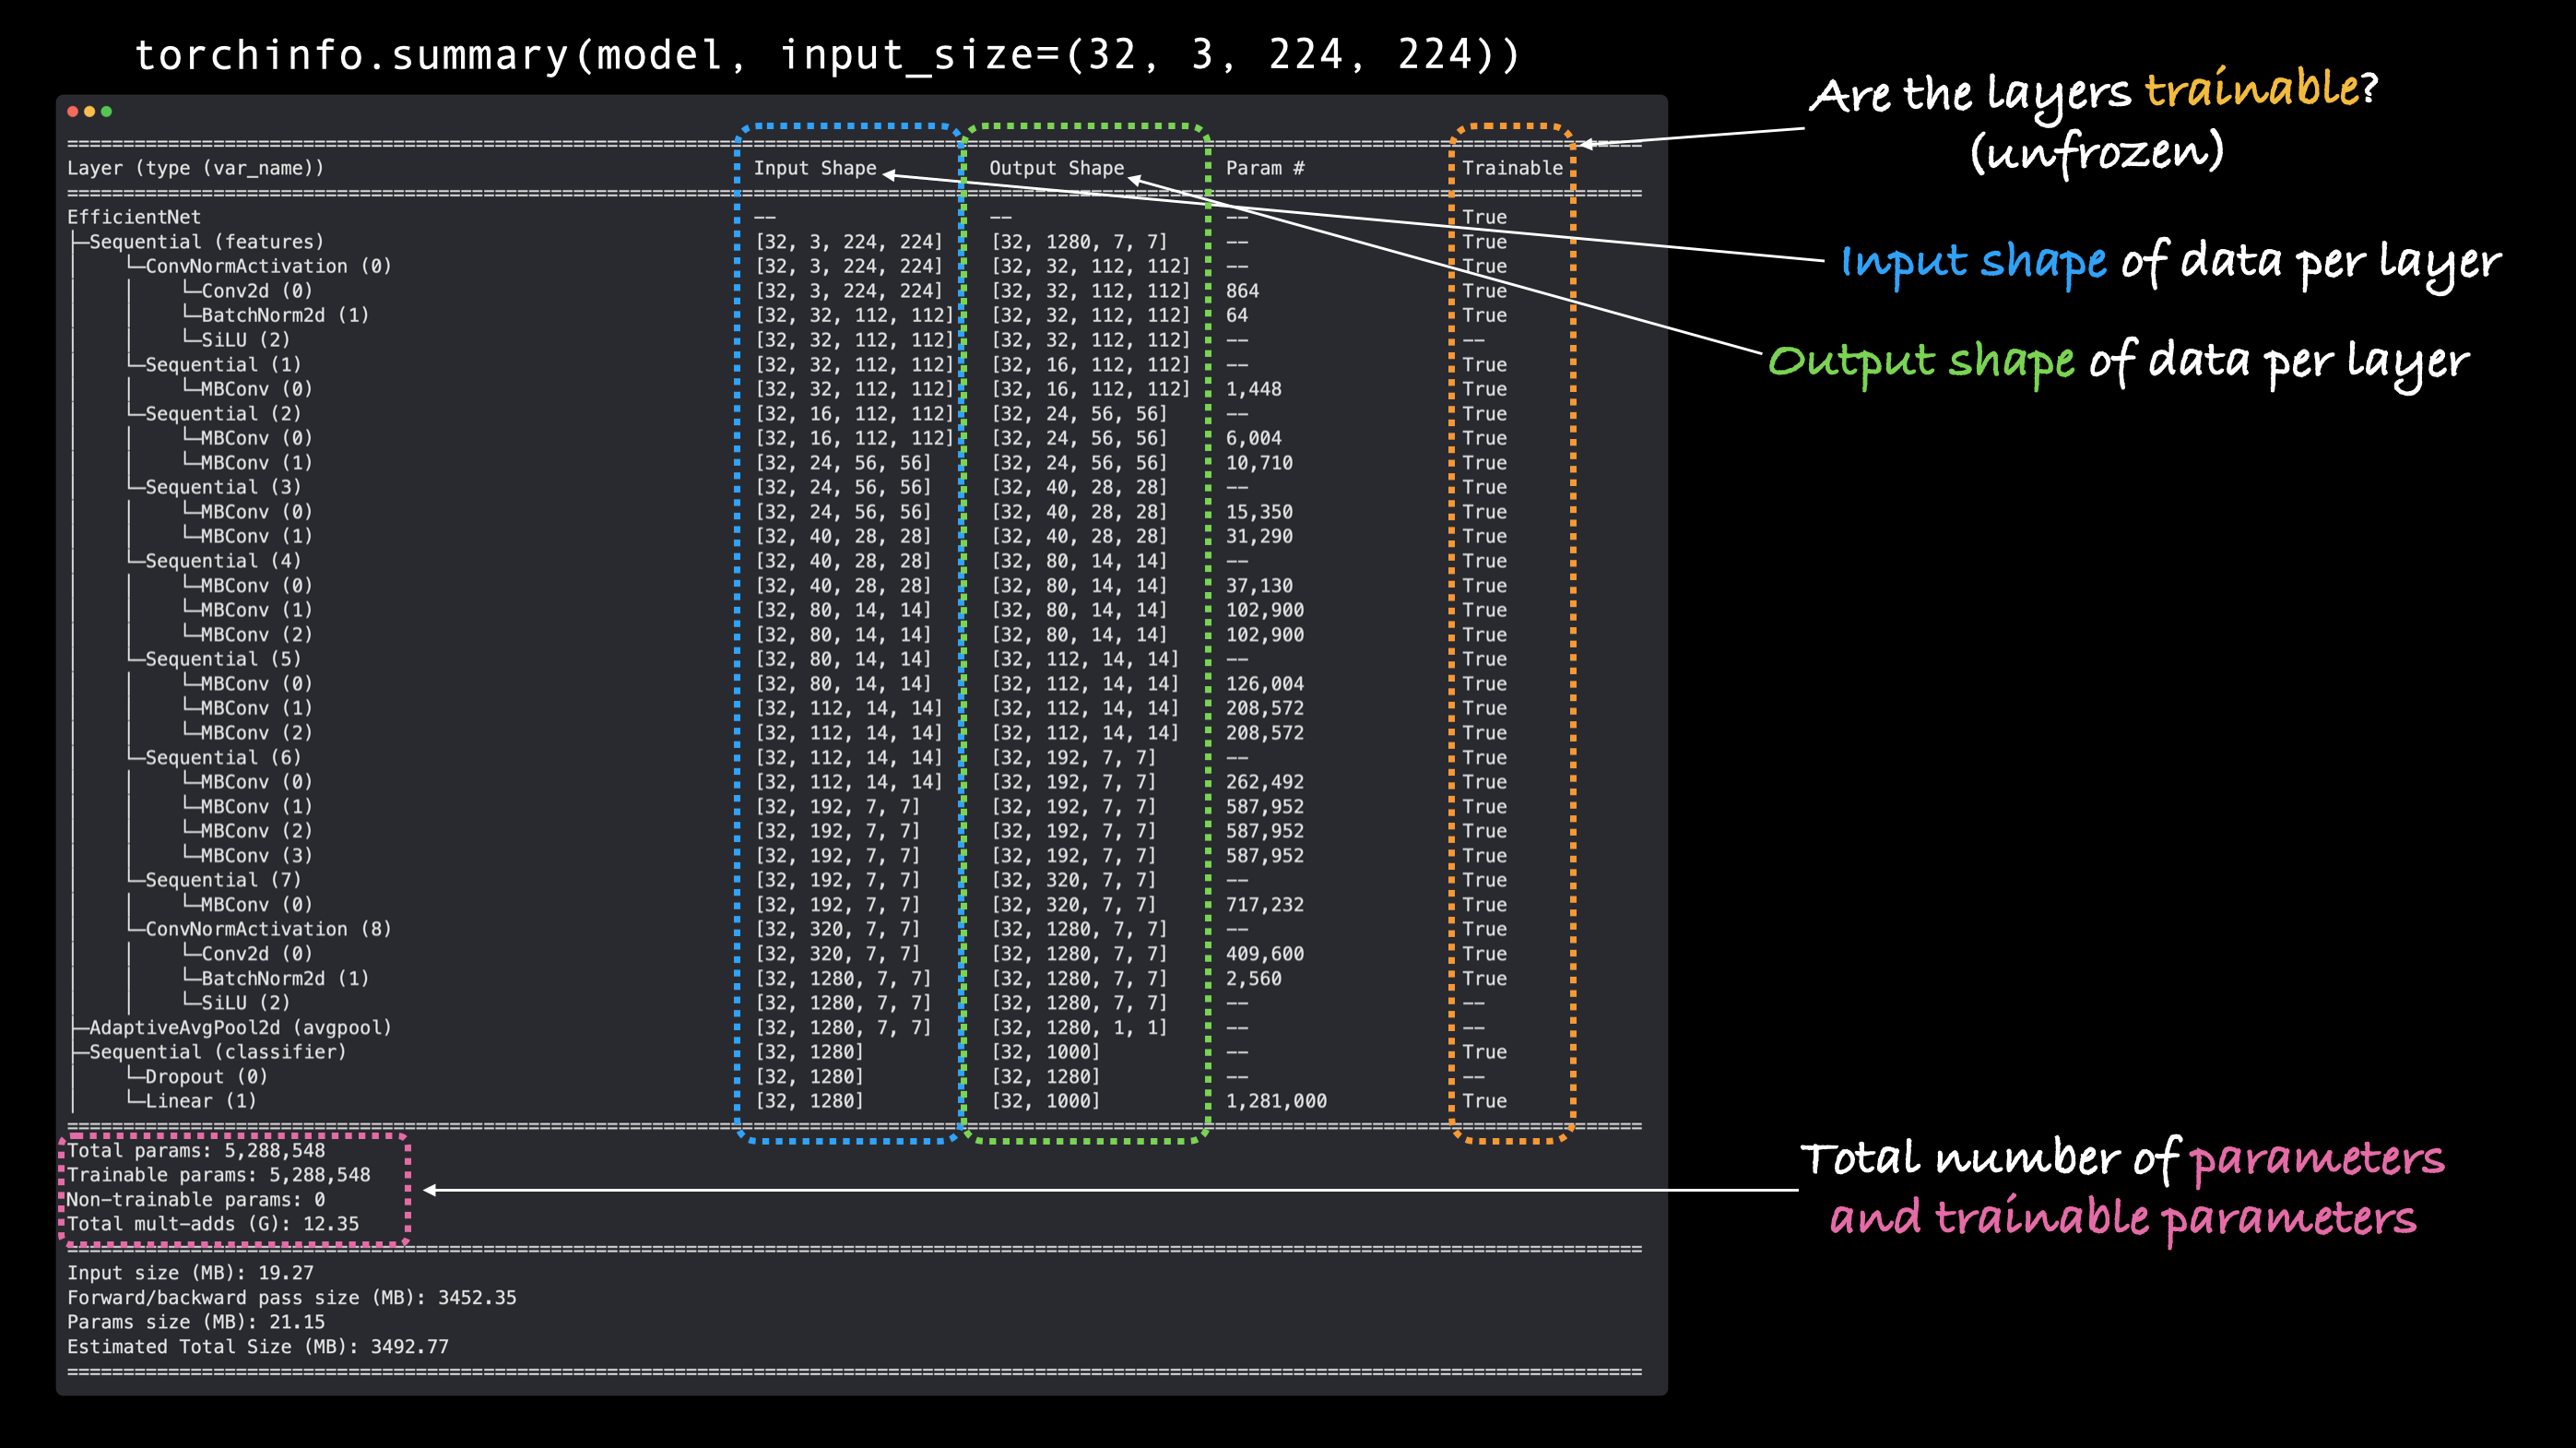

### 3.4 Freezing the base model and changing the output layer to suit our needs

The process of transfer learning usually goes: freeze some base layers of a pretrained model (typically the features section) and then adjust the output layers (also called head/classifier layers) to suit your needs.

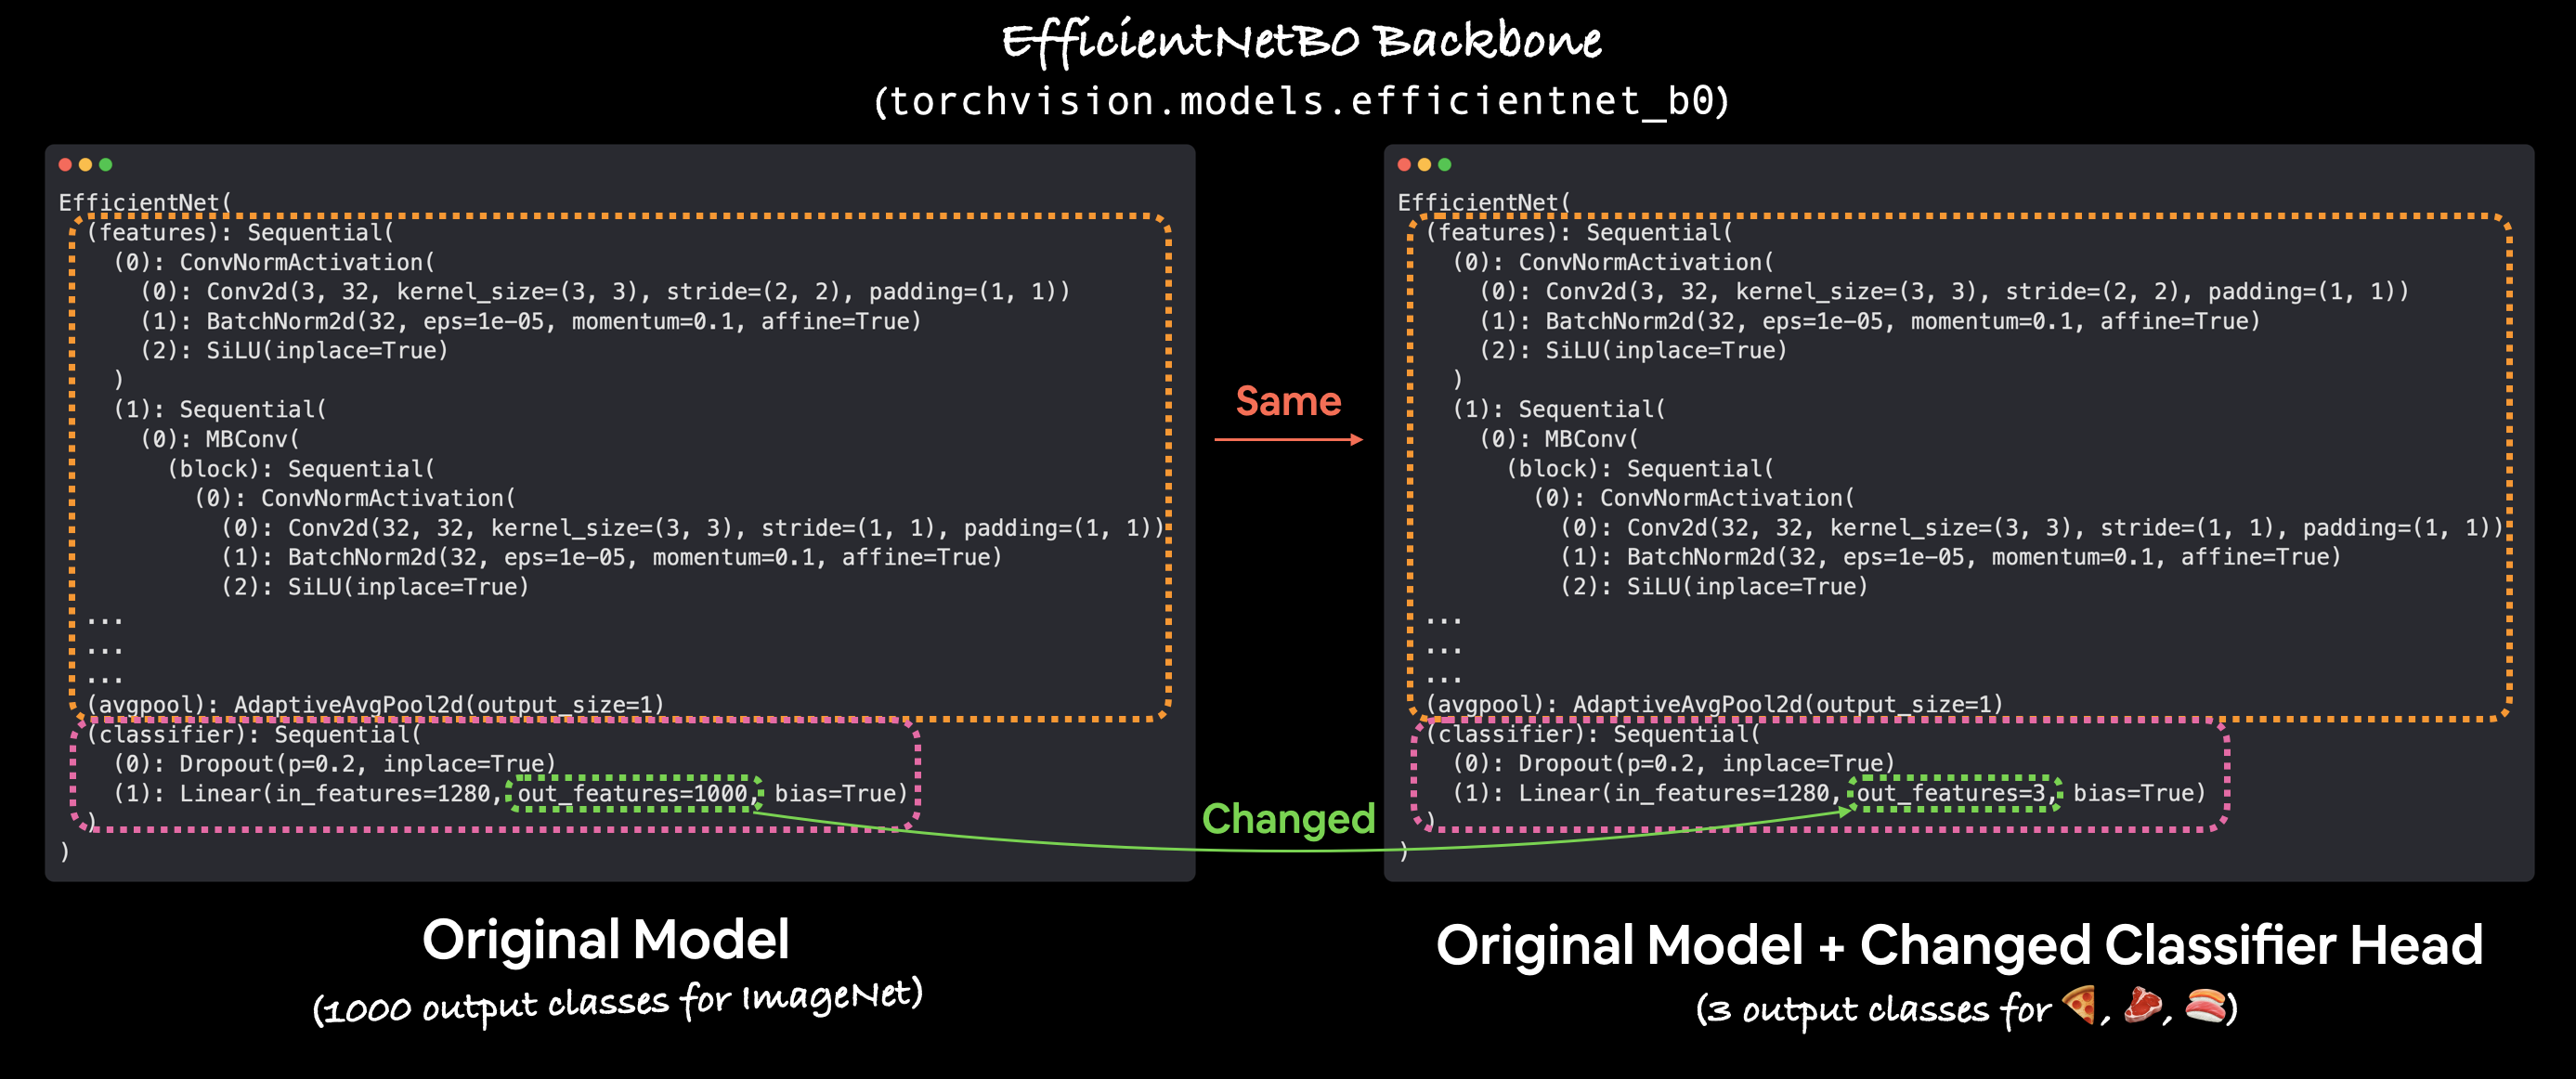

we can customise the outputs of a pretrained model by changing the output layer(s) to suit your problem. The original torchvision.models.efficientnet_b0() comes with **out_features=1000 because there are 1000 classes in ImageNet**, the dataset it was trained on. However, **for our problem, classifying images of pizza, steak and sushi we only need out_features=3.**

`We can freeze all of the layers/parameters in the features section by setting the attribute requires_grad=False.`

For parameters with **requires_grad=False**, PyTorch doesn't track gradient updates and in turn, these parameters won't be changed by our optimizer during training.

In essence, **a parameter with requires_grad=False is "untrainable" or "frozen" in place.**

In [12]:
for param in model.features.parameters():
    param.requires_grad = False

We can change the `classifier` portion of our model by creating a new series of layers.

The current `classifier` consists of:


(classifier): Sequential(
    (0): Dropout(p=0.2, inplace=True)
    (1): Linear(in_features=1280, out_features=1000, bias=True)

`We'll keep the Dropout layer the same using torch.nn.Dropout(p=0.2, inplace=True).`

And we'll keep in_features=1280 for our `Linear output layer` but we'll `change the out_features value to the length of our class_names (len(['pizza', 'steak', 'sushi']) = 3).`

Our new classifier layer should be on the same device as our model.

In [13]:
#Set the manual seed
import torch
torch.manual_seed(42)

output_shape = len(class_names)

model.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p = 0.2,inplace = True),
    torch.nn.Linear(in_features= 1280,out_features=output_shape,bias=True,)
).to(device)

In [15]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001)

In [17]:
#Set the manual seed
torch.manual_seed(42)
torch.cuda.manual_seed(42)
import engine


from timeit import default_timer as timer
start_time = timer()

results = engine.train(model = model,train_dataloader = train_dataloader,
test_dataloader = test_dataloader,optimizer = optimizer , loss_fn = loss_fn,
epochs = 5 ,device = device)

end_time = timer()

print(f"[INFO] Total training time : {end_time - start_time:.3f} seconds")



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.5413 | train_acc: 0.9414 | test_loss: 0.5672 | test_acc: 0.9072
Epoch: 2 | train_loss: 0.4872 | train_acc: 0.9492 | test_loss: 0.5066 | test_acc: 0.8864
Epoch: 3 | train_loss: 0.4754 | train_acc: 0.9219 | test_loss: 0.4976 | test_acc: 0.9072
Epoch: 4 | train_loss: 0.4794 | train_acc: 0.8477 | test_loss: 0.4755 | test_acc: 0.8864
Epoch: 5 | train_loss: 0.4212 | train_acc: 0.9492 | test_loss: 0.4841 | test_acc: 0.9176
[INFO] Total training time : 5.860 seconds


### 5.Evaluate model by plotting loss curves


In [ ]:
from helper_function import plot_loss_curves    